Import Libraries and Functions

In [2]:
import os
if not "src" in os.listdir(): # I use this to change my directory to access the src and data folders from in here
    os.chdir("..") 
# print(os.listdir()) # this should say something like ['README.md', 'wk5_toolbox', '.git', 'wk4_toolbox']

import networkx as nx

import numpy as np
import scipy as sp
import pandas as pd

import mygene # allow us to convert from systematic to standard

import matplotlib.pyplot as plt

from src.reading_in import read_in_proteins
from src.community_finding import partition_graph, partition_graph_size, eliminate_small_communities, get_adjacent_communities
from wk6_toolbox.wk6_subroutines import all_shortest_paths, sort_proteins_by_frequency

FILEPATH = "data/raw/protein.links.v12.0.txt.gz"
G = read_in_proteins(include_essential_proteins=False, connected=True)

compute communitites, get adjacent communitites & find representatives

In [3]:
communities = partition_graph(G, seed=None)

In [4]:
adjacent_communities = get_adjacent_communities(G, communities)

# TODO must be a better method, I'm literally just picking the highest degree node
adjacent_representatives = [
    max(community, key=lambda n: G.degree(n))
    for community in adjacent_communities
]
print(len(adjacent_representatives))

15


for now, pick a random adjacent community, we will need biochem's help with this.

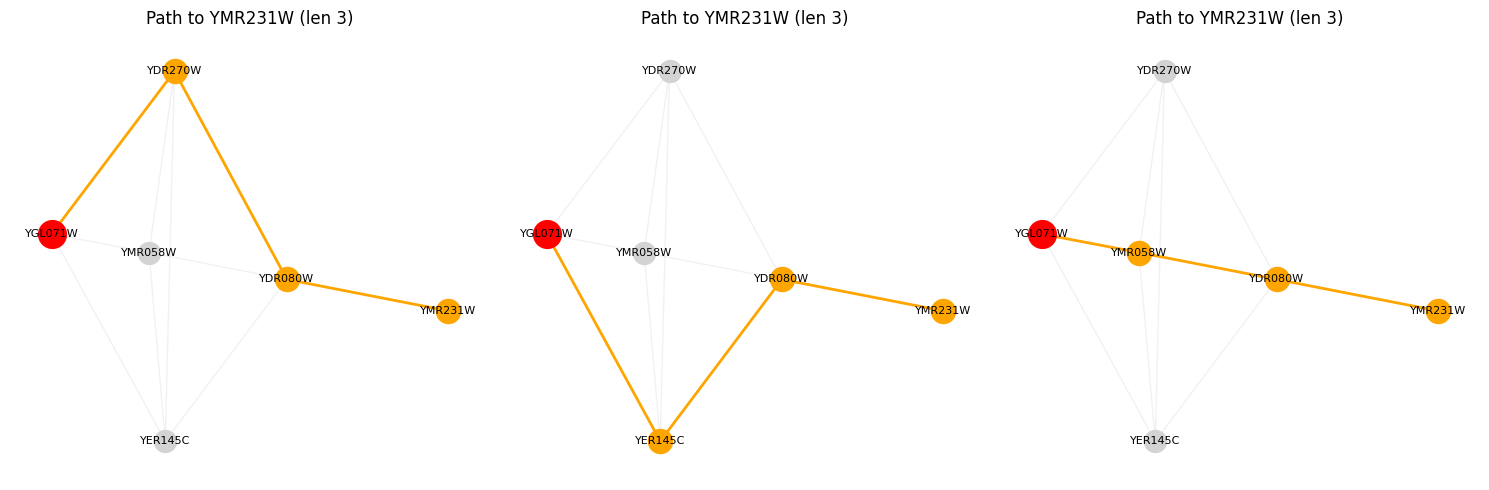

In [5]:
source = str(np.random.choice(adjacent_representatives))
paths = all_shortest_paths(G, source)  # list of paths (each a list of nodes)

# Union of all nodes that appear in any path
nodes_in_paths = set()
for path in paths:
    nodes_in_paths.update(path)

# Subgraph containing only those nodes (and edges between them that exist in G)
H = G.subgraph(nodes_in_paths)

# Layout computed once on the small subgraph, reused across all panels
pos = nx.spring_layout(H)

n = len(paths)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

for ax, path in zip(axes, paths):
    path_edges = list(zip(path, path[1:]))

    # background: just the reduced subgraph, faded
    nx.draw_networkx_nodes(H, pos, ax=ax, node_color='lightgray', node_size=250)
    nx.draw_networkx_edges(H, pos, ax=ax, edge_color='lightgray', alpha=0.3)

    # highlight this path
    nx.draw_networkx_nodes(H, pos, nodelist=path, ax=ax, node_color='orange', node_size=300)
    nx.draw_networkx_nodes(H, pos, nodelist=[source], ax=ax, node_color='red', node_size=400)
    nx.draw_networkx_edges(H, pos, edgelist=path_edges, ax=ax, edge_color='orange', width=2)

    nx.draw_networkx_labels(H, pos, ax=ax, font_size=8)
    ax.set_title(f"Path to {path[-1]} (len {len(path)-1})")
    ax.axis('off')

plt.tight_layout()
plt.show()

compute top 3 important nodes.

In [7]:
# TODO
shortest_path_frequencies = sort_proteins_by_frequency(paths)
print(shortest_path_frequencies[0], shortest_path_frequencies[1], shortest_path_frequencies[2])

('YGL071W', 4) ('YDR080W', 4) ('YMR231W', 4)
